# 🧠 NeuroVision‑AI
## AI‑Powered Brain Tumor Classification using Convolutional Neural Networks

This notebook builds an end‑to‑end deep learning pipeline to classify brain MRI images into **Glioma**, **Meningioma**, **Pituitary** tumors, and **No Tumor**.

We use **transfer learning** with **EfficientNetB0** for high accuracy, apply data augmentation, and visualize model decisions with Grad‑CAM.

---

## 1. Setup and Imports

In [1]:
# Core
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import glob
import zipfile

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Grad-CAM
import tensorflow as tf

# For generating PowerPoint (install python-pptx if not available)
!pip install python-pptx -q
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN
from pptx.dml.color import RGBColor

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Load and Prepare Dataset

We assume the dataset is in the following structure:

```
dataset/
├── Training/
│   ├── glioma/
│   ├── meningioma/
│   ├── pituitary/
│   └── notumor/
└── Testing/
    ├── glioma/
    ├── meningioma/
    ├── pituitary/
    └── notumor/
```

If you don't have the dataset, download it from [Kaggle](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset) and place it in the project folder.

In [17]:
# Paths
TRAIN_DIR = './README.md/dataset/training dataset'
TEST_DIR = './README.md/dataset/testing dataset'


# Image dimensions (EfficientNetB0 expects 224x224)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data generators with augmentation for training
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of training images:", train_generator.samples)
print("Number of test images:", test_generator.samples)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of training images: 5600
Number of test images: 1600


## 3. Build the Model with Transfer Learning

We use **EfficientNetB0** (pre‑trained on ImageNet) as the base and add custom classification layers on top.

In [3]:
# Base model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base initially

# Build the full model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,559 (16.71 MB)

 Trainable params: 329,476 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

## 4. Train the Model

We use callbacks: EarlyStopping, ReduceLROnPlateau, and ModelCheckpoint to save the best model.

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=30,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7
    ),
    ModelCheckpoint(
        'best_model.keras',
        save_best_only=True,
        monitor='val_accuracy',
        mode='max'
    )
]

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=test_generator,
    callbacks=callbacks
)

Epoch 1/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.9887 - loss: 0.0360

175/175 ━━━━━━━━━━━━━━━━━━━━ 96s 545ms/step - accuracy: 0.9887 - loss: 0.0360 - val_accuracy: 0.9519 - val_loss: 0.3117 - learning_rate: 8.0000e-07
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 92s 522ms/step - accuracy: 0.9895 - loss: 0.0314 - val_accuracy: 0.9519 - val_loss: 0.3099 - learning_rate: 8.0000e-07
Epoch 3/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 91s 521ms/step - accuracy: 0.9921 - loss: 0.0278 - val_accuracy: 0.9519 - val_loss: 0.3084 - learning_rate: 8.0000e-07
Epoch 4/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.9920 - loss: 0.0264

175/175 ━━━━━━━━━━━━━━━━━━━━ 92s 524ms/step - accuracy: 0.9920 - loss: 0.0264 - val_accuracy: 0.9525 - val_loss: 0.3079 - learning_rate: 8.0000e-07
Epoch 5/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 93s 528ms/step - accuracy: 0.9879 - loss: 0.0368 - val_accuracy: 0.9525 - val_loss: 0.3101 - learning_rate: 8.0000e-07
Epoch 6/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 91s 522ms/step - accuracy: 0.9896 - loss: 0.0298 - val_accuracy: 0.9525 - val_loss: 0.3090 - learning_rate: 8.0000e-07
Epoch 7/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 92s 527ms/step - accuracy: 0.9909 - loss: 0.0277 - val_accuracy: 0.9525 - val_loss: 0.3116 - learning_rate: 8.0000e-07
Epoch 8/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.9884 - loss: 0.0325

175/175 ━━━━━━━━━━━━━━━━━━━━ 94s 538ms/step - accuracy: 0.9884 - loss: 0.0325 - val_accuracy: 0.9538 - val_loss: 0.3060 - learning_rate: 1.6000e-07
Epoch 9/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 93s 529ms/step - accuracy: 0.9907 - loss: 0.0312 - val_accuracy: 0.9519 - val_loss: 0.3083 - learning_rate: 1.6000e-07
Epoch 10/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 92s 526ms/step - accuracy: 0.9905 - loss: 0.0304 - val_accuracy: 0.9531 - val_loss: 0.3069 - learning_rate: 1.6000e-07
Epoch 11/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 93s 529ms/step - accuracy: 0.9911 - loss: 0.0285 - val_accuracy: 0.9525 - val_loss: 0.3092 - learning_rate: 1.6000e-07
Epoch 12/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 93s 528ms/step - accuracy: 0.9923 - loss: 0.0278 - val_accuracy: 0.9525 - val_loss: 0.3109 - learning_rate: 1.0000e-07
Epoch 13/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 93s 532ms/step - accuracy: 0.9923 - loss: 0.0293 - val_accuracy: 0.9525 - val_loss: 0.3105 - learning_rate: 1.0000e-07


## 5. Fine‑tune the Model (Optional)

Unfreeze the top layers of the base model and train with a lower learning rate to improve accuracy.

In [5]:
# Unfreeze the base model from layer 100 onwards
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_fine = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    callbacks=callbacks
)

# Combine history for plotting
for key in history.history.keys():
    history.history[key].extend(history_fine.history[key])

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 110s 548ms/step - accuracy: 0.8523 - loss: 0.4460 - val_accuracy: 0.8963 - val_loss: 0.3616 - learning_rate: 1.0000e-04
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.9302 - loss: 0.1999

175/175 ━━━━━━━━━━━━━━━━━━━━ 95s 540ms/step - accuracy: 0.9302 - loss: 0.1999 - val_accuracy: 0.9250 - val_loss: 0.3767 - learning_rate: 1.0000e-04
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.9505 - loss: 0.1315

175/175 ━━━━━━━━━━━━━━━━━━━━ 96s 549ms/step - accuracy: 0.9505 - loss: 0.1315 - val_accuracy: 0.9287 - val_loss: 0.3810 - learning_rate: 1.0000e-04
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 101s 575ms/step - accuracy: 0.9652 - loss: 0.0981 - val_accuracy: 0.9237 - val_loss: 0.3650 - learning_rate: 1.0000e-04
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.9770 - loss: 0.0661

175/175 ━━━━━━━━━━━━━━━━━━━━ 94s 537ms/step - accuracy: 0.9770 - loss: 0.0661 - val_accuracy: 0.9356 - val_loss: 0.3267 - learning_rate: 2.0000e-05
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.9809 - loss: 0.0548

175/175 ━━━━━━━━━━━━━━━━━━━━ 94s 535ms/step - accuracy: 0.9809 - loss: 0.0548 - val_accuracy: 0.9413 - val_loss: 0.3229 - learning_rate: 2.0000e-05
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 94s 539ms/step - accuracy: 0.9787 - loss: 0.0640 - val_accuracy: 0.9400 - val_loss: 0.3266 - learning_rate: 2.0000e-05
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.9836 - loss: 0.0536

175/175 ━━━━━━━━━━━━━━━━━━━━ 96s 549ms/step - accuracy: 0.9836 - loss: 0.0536 - val_accuracy: 0.9463 - val_loss: 0.3183 - learning_rate: 2.0000e-05
Epoch 9/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 95s 544ms/step - accuracy: 0.9821 - loss: 0.0533 - val_accuracy: 0.9463 - val_loss: 0.3193 - learning_rate: 2.0000e-05
Epoch 10/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.9804 - loss: 0.0537

175/175 ━━━━━━━━━━━━━━━━━━━━ 95s 541ms/step - accuracy: 0.9804 - loss: 0.0537 - val_accuracy: 0.9488 - val_loss: 0.3073 - learning_rate: 2.0000e-05


## 6. Evaluate the Model

Compute accuracy, precision, recall, F1‑score, confusion matrix, and classification report.

50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 203ms/step
Test Accuracy: 0.9487
Weighted Precision: 0.9512
Weighted Recall: 0.9487
Weighted F1-Score: 0.9476

Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.83      0.90       400
  meningioma       0.90      0.97      0.93       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.98      1.00      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



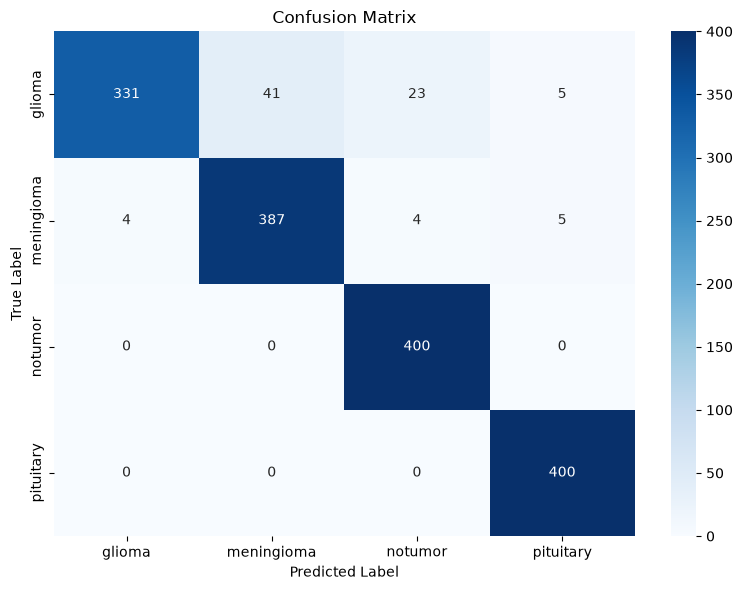

In [ ]:
# Lad the best saved mdel
model = tf.keras.models.load_model('best_model.keras')

# Predict on test set
test_generator.reset()

predictions = model.predict(
    test_generator,
    verbose=1
)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Test Accuracy: {acc:.4f}")
print(f"Weighted Precision: {prec:.4f}")
print(f"Weighted Recall: {rec:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# 6.1 Visualize Test MRI Images

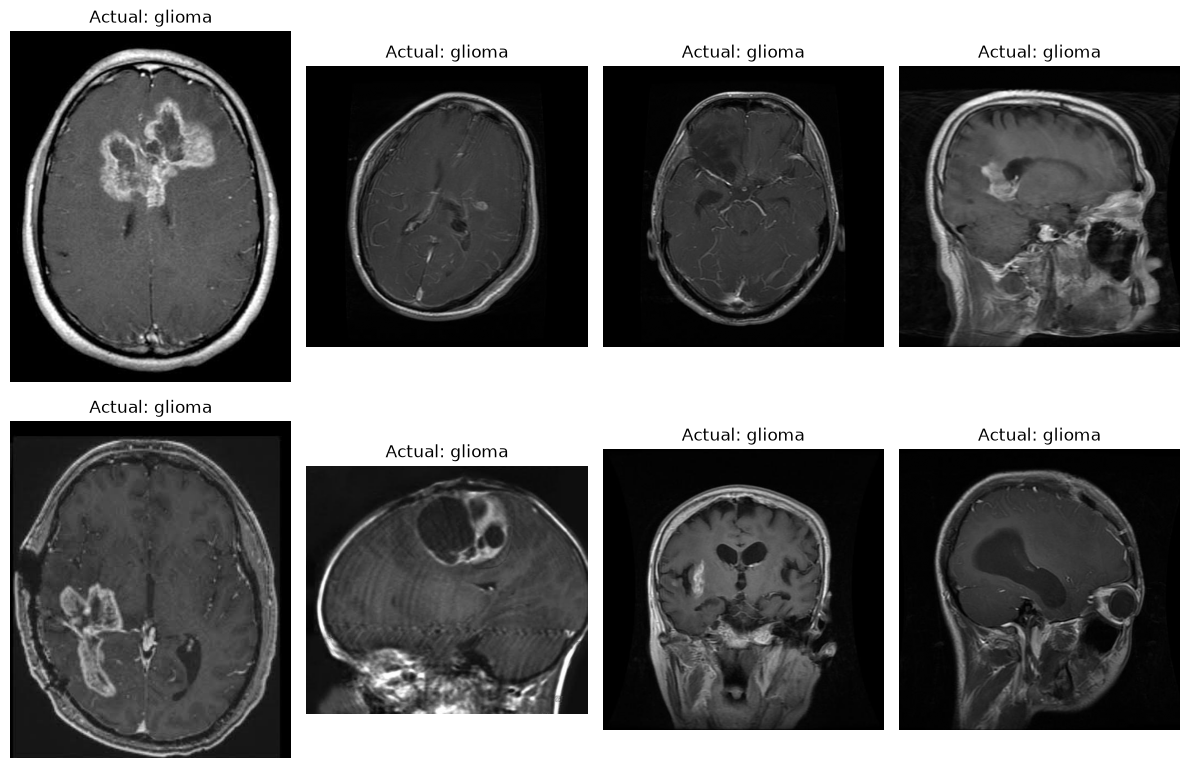

In [7]:
# ============================================================
# DISPLAY SAMPLE MRI IMAGES
# ============================================================

plt.figure(figsize=(12, 8))

for i in range(8):

    image_path = test_generator.filepaths[i]

    image = Image.open(image_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image, cmap="gray")

    actual_class = class_names[
        test_generator.classes[i]
    ]

    plt.title(f"Actual: {actual_class}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6.2 Sample Predictions

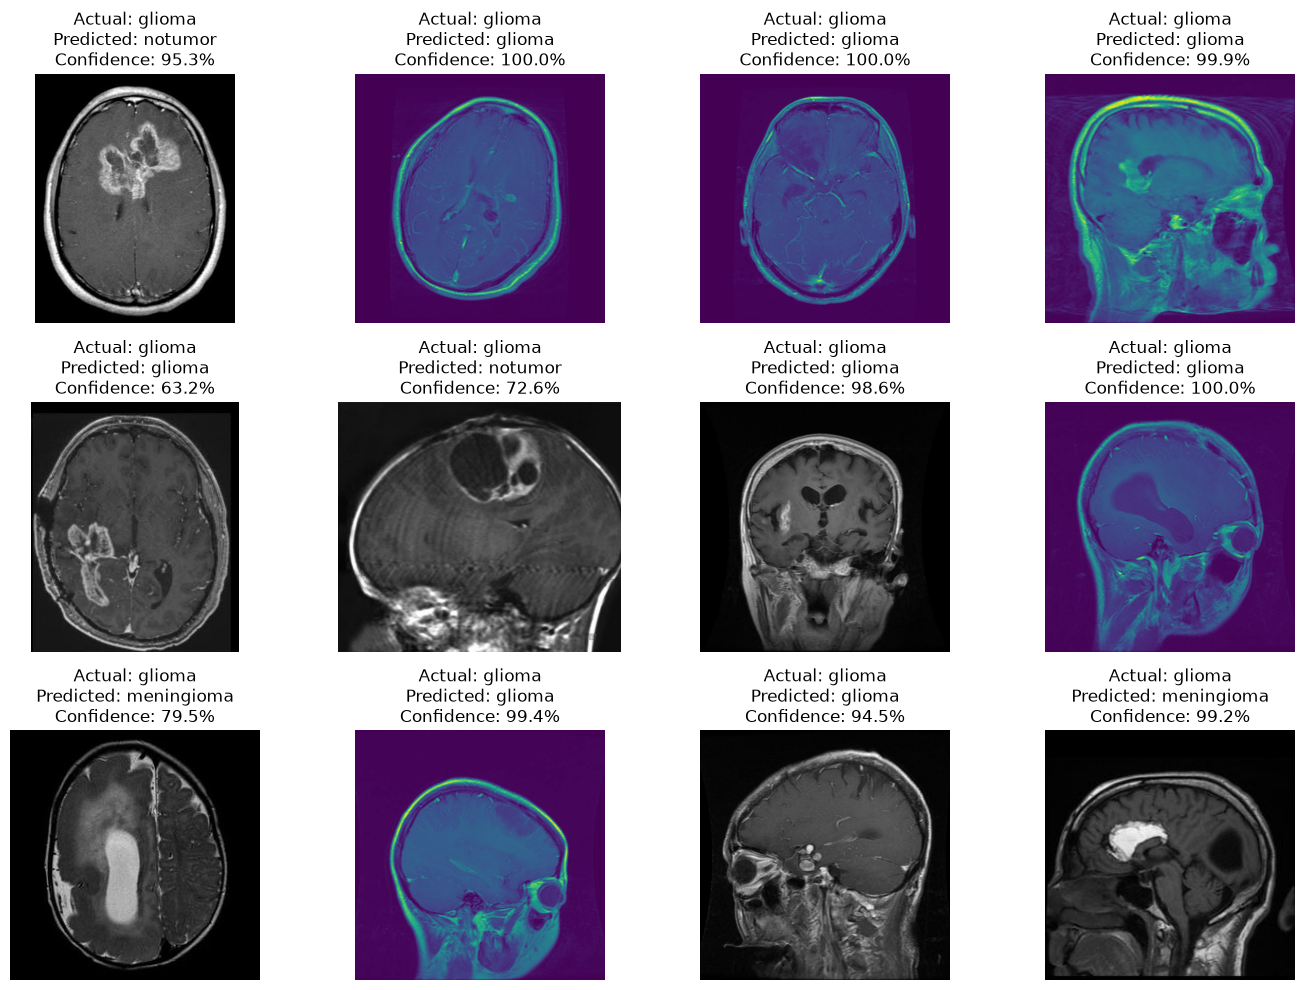

In [8]:
# ============================================================
# SHOW ACTUAL VS PREDICTED RESULTS
# ============================================================

plt.figure(figsize=(14, 10))

for i in range(12):

    image_path = test_generator.filepaths[i]

    image = Image.open(image_path)

    actual_index = y_true[i]
    predicted_index = y_pred[i]

    actual_class = class_names[actual_index]
    predicted_class = class_names[predicted_index]

    confidence = predictions[i][predicted_index] * 100

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(
        f"Actual: {actual_class}\n"
        f"Predicted: {predicted_class}\n"
        f"Confidence: {confidence:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.savefig(
    "sample_predictions.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

## 7. Visualize Training History

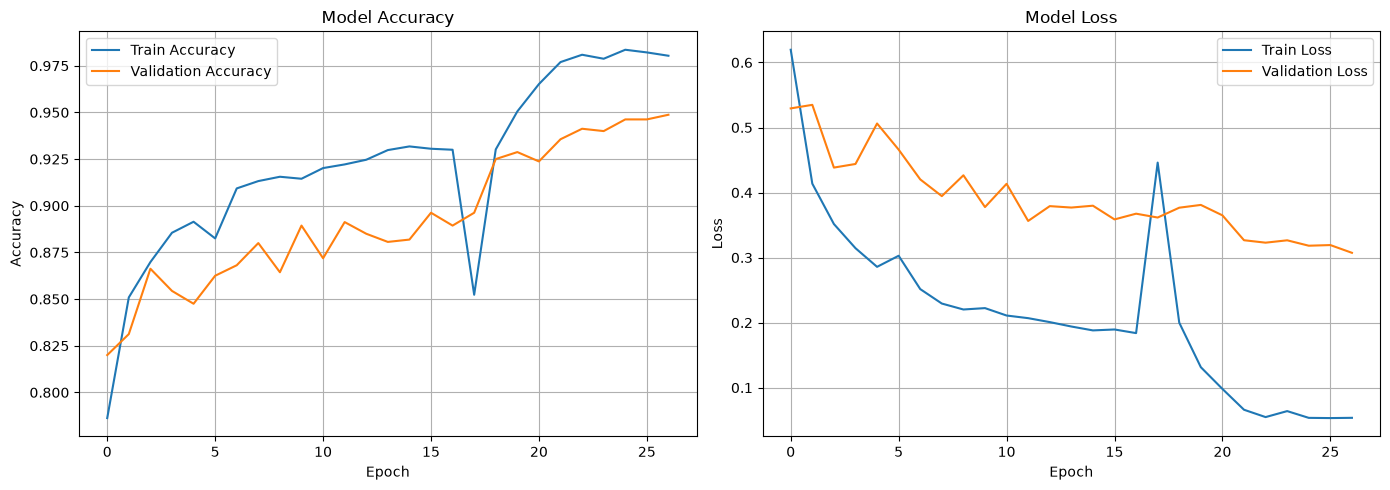

In [9]:
# Plot accuracy and loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

## 8. Explainability with Grad‑CAM

We generate a heatmap overlay on an input image to show which regions the model focuses on for its decision.

In [10]:
# ============================================================
# GRAD-CAM SETUP
# ============================================================

efficientnet = model.get_layer("efficientnetb0")

target_layer = efficientnet.get_layer("top_activation")

print("Grad-CAM layer:", target_layer.name)
print("Output shape:", target_layer.output.shape)

Grad-CAM layer: top_activation
Output shape: (None, 7, 7, 1280)


## 8.1 Grad-CAM Visualization

In [22]:
# ============================================================
# GRAD-CAM - KERAS 3 / TENSORFLOW 2.21 COMPATIBLE
# ============================================================

def get_gradcam_heatmap(model, img_array, target_layer):

    # --------------------------------------------------------
    # Find EfficientNet inside the Sequential model
    # --------------------------------------------------------
    efficientnet = model.get_layer("efficientnetb0")

    # Make sure the complete model has been called
    _ = model(img_array, training=False)

    # --------------------------------------------------------
    # Create Grad-CAM model using the EfficientNet input
    # --------------------------------------------------------
    grad_model = tf.keras.models.Model(
        inputs=efficientnet.input,
        outputs=[
            target_layer.output,
            efficientnet.output
        ]
    )

    with tf.GradientTape() as tape:

        # Run EfficientNet
        conv_outputs, efficientnet_features = grad_model(
            img_array,
            training=False
        )

        # Continue through the remaining layers
        x = efficientnet_features

        # Find layers after EfficientNet
        efficientnet_index = model.layers.index(
            efficientnet
        )

        for layer in model.layers[efficientnet_index + 1:]:
            x = layer(x, training=False)

        predictions = x

        # Predicted class
        predicted_class = tf.argmax(
            predictions[0]
        )

        # Score for predicted class
        class_score = predictions[:, predicted_class]

    # --------------------------------------------------------
    # Calculate gradients
    # --------------------------------------------------------
    grads = tape.gradient(
        class_score,
        conv_outputs
    )

    if grads is None:
        raise ValueError(
            "Gradients are None. "
            "The target layer is not connected correctly."
        )

    # --------------------------------------------------------
    # Average gradients
    # --------------------------------------------------------
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Weight feature maps
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    heatmap = heatmap / (
        tf.reduce_max(heatmap)
        + tf.keras.backend.epsilon()
    )

    return (
        heatmap.numpy(),
        int(predicted_class.numpy())
    )

In [23]:
print("Model:", model.name)
print("Target layer:", target_layer.name)
print("Target layer output:", target_layer.output.shape)
print("Final layer:", model.layers[-1].name)

Model: sequential
Target layer: top_activation
Target layer output: (None, 7, 7, 1280)
Final layer: dense_1


In [24]:
def display_gradcam(image_path, heatmap, predicted_class, confidence):

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    heatmap_uint8 = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    heatmap_color = cv2.resize(
        heatmap_color,
        (img.shape[1], img.shape[0])
    )

    overlay = cv2.addWeighted(
        img,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original MRI")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

## 8.2 Generate Grad-CAM

Image: ./README.md/dataset/testing dataset/glioma/Te-gl_1.jpg
Prediction: notumor
Confidence: 86.68%


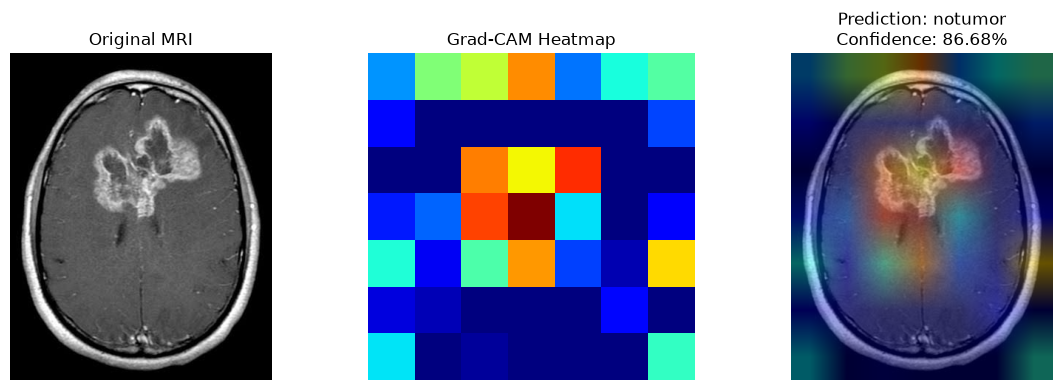

In [25]:
# ============================================================
# GENERATE GRAD-CAM FOR A TEST IMAGE
# ============================================================

sample_img_path = test_generator.filepaths[0]

print("Image:", sample_img_path)


# Load image
img = tf.keras.preprocessing.image.load_img(
    sample_img_path,
    target_size=IMG_SIZE
)

img_array = tf.keras.preprocessing.image.img_to_array(
    img
)

img_array = preprocess_input(
    img_array
)

img_array = np.expand_dims(
    img_array,
    axis=0
)


# Prediction
predictions_single = model.predict(
    img_array,
    verbose=0
)

predicted_index = np.argmax(
    predictions_single[0]
)

predicted_class = class_names[
    predicted_index
]

confidence = (
    predictions_single[0][predicted_index] * 100
)


print("Prediction:", predicted_class)
print(f"Confidence: {confidence:.2f}%")


# Grad-CAM
heatmap, predicted_class_index = get_gradcam_heatmap(
    model,
    img_array,
    target_layer
)

# Display
display_gradcam(
    sample_img_path,
    heatmap,
    predicted_class,
    confidence
)

## 9. Save the Final Model

In [21]:
model.save('brain_tumor_model.keras')
print("Model saved as 'brain_tumor_model.keras'")

# Also save the training history as CSV
pd.DataFrame(history.history).to_csv('training_history.csv', index=False)

Model saved as 'brain_tumor_model.keras'
